In [38]:
#%pip install opencv-python --break-system-packages
#%pip install matplotlib --break-system-packages
#%pip install --upgrade numpy opencv-python matplotlib --break-system-packages
#%pip install pandas --break-system-packages
#%pip install scipy --break-system-packages

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse
import cv2

img_bgr = cv2.imread('mountain.jpg')
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

img_test = np.array([[0, 0, 1, 1, 1, 0, 0],
                    [0, 0, 1, 0, 1, 0, 0],
                    [0, 0, 1, 0, 1, 0, 0],
                    [0, 0, 1, 1, 1, 0, 0],
                    [0, 0, 1, 0, 1, 0, 0],
                    [0, 0, 1, 0, 1, 0, 0],
                    [0, 0, 1, 1, 1, 0, 0]]) * 255


#cv2.imshow('image', img_test)
#cv2.waitKey(0)
#cv2.destroyAllWindows()


In [40]:
g = img_test
lamb = 1
eps = 1e-5
alpha = 1

nb_lignes, nb_colonnes = g.shape


In [ ]:
# Matrice Creuse Dx
n = nb_lignes * nb_colonnes

diagonals = [-np.ones(n), np.ones(n-1)]
Dx = sparse.diags(diagonals, [0, 1], shape=(n, n), format="csr", dtype='float32')

# Matrice Creuse Dy A VERIFIER C4EST DE LA MERDE
m = nb_colonnes

diagonals = [-np.ones(n), np.ones(n - m)]
Dy = sparse.diags(diagonals, [0, m], shape=(n, n), format="csr", dtype='float32')

In [42]:
ax_flat = np.gradient(g)[0].flatten()
ay_flat = np.gradient(g)[1].flatten()

ax_weights = (np.abs(ax_flat)**alpha + eps)**(-1)
ay_weights = (np.abs(ay_flat)**alpha + eps)**(-1)

Ax = sparse.diags(ax_weights, format="csr", dtype='float32')
Ay = sparse.diags(ay_weights, format="csr", dtype='float32')

In [43]:
g = g.ravel()

Lg = Dx.T @ Ax @ Dx + Dy.T @ Ay @ Dy

I = sparse.eye(n, format="csr", dtype='float32')

A_system = I + lamb * Lg
u, info = sparse.linalg.cg(A_system, g, tol=1e-5, maxiter=1e4)


u = u.reshape(nb_lignes, nb_colonnes)


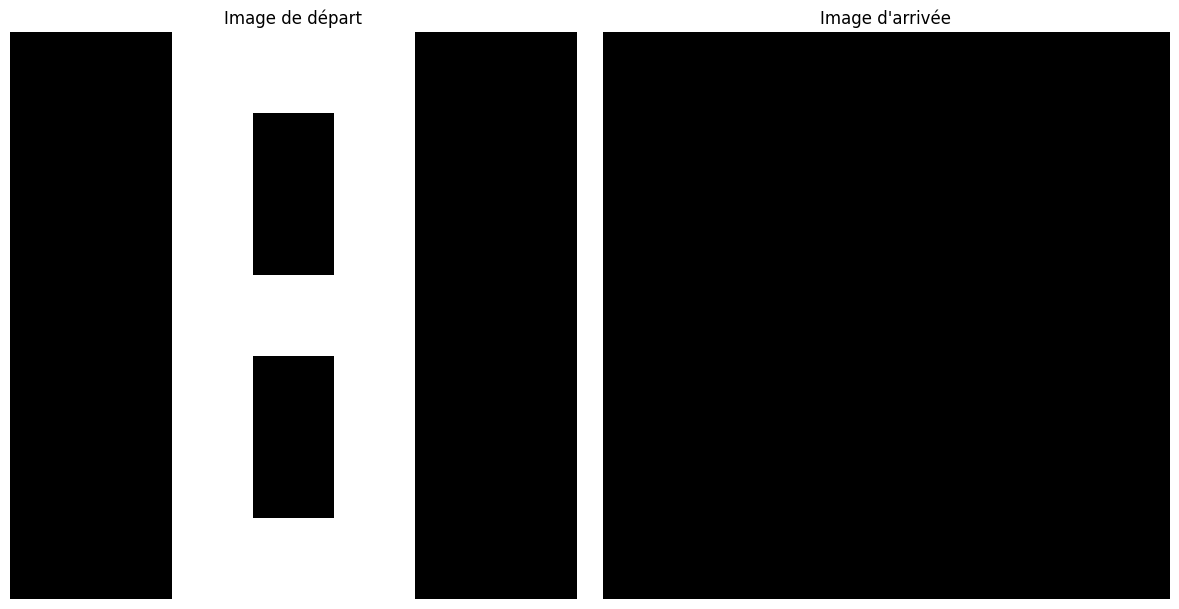

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(img_test, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Image de départ')
axes[0].axis('off')

axes[1].imshow(u, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Image d'arrivée")
axes[1].axis('off')

plt.tight_layout()
plt.show()